# 07 — Model 2 & Model 4: Dari Permukaan ke Kilogram

Detektor menjawab *di mana*, head kematangan menjawab *seberapa matang*.
Notebook ini menjawab dua pertanyaan berikutnya:

| Model | Pertanyaan | Keluaran |
|---|---|---|
| **Model 2** | Komposisi SELURUH muatan, padahal kamera hanya melihat permukaan | proporsi ± selang |
| **Model 4** | Berapa KILOGRAM minyak ada di truk ini | kg ± selang |

## Persoalan Model 2 bukan klasifikasi

Ini **inferensi statistik di bawah observasi parsial** — menaksir distribusi
populasi dari cuplikan yang bias. Dua sumber ketidakpastiannya berbeda sifat,
dan hanya satu yang bisa dikurangi:

1. **Bias sistematis** — permukaan tidak mewakili keseluruhan. Tandan besar
   tenggelam; buah bagus kadang sengaja ditaruh di atas. Bias ini yang
   dikoreksi model.

2. **Galat pencuplikan** — dengan n tandan terlihat dari muatan berisi
   ratusan, galat baku proporsi adalah `sqrt(p(1-p)/n)`. Ini **lantai
   teoretis**. Model yang melaporkan selang lebih sempit dari lantai ini
   bukan pintar, melainkan berbohong.

Karena itu notebook ini tidak hanya melaporkan akurasi, tetapi juga
memeriksa apakah lebar selangnya **jujur** terhadap lantai tersebut.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parents[1]))
import vizstyle as vs
vs.apply_style()

from ai.perception import composition as M2
from ai.perception import potential as M4
from ai.config import coefficients as C

ROOT = Path.cwd().parents[1]
df = pd.read_parquet(ROOT / "data" / "processed" / "stack_sintetik" / "muatan_sintetik.parquet")
model = M2.Model2.muat()

KELAS = M2.NAMA_KELAS
LABEL = ["mentah", "kurang\nmasak", "masak", "terlalu\nmasak"]
RAMP = vs.ORDINAL_RAMP

te = df[df.split == "test"]
print(f"muatan sintetik: {len(df):,}  (uji {len(te):,})")
print(f"koreksi conformal: {model.koreksi}")

muatan sintetik: 45,000  (uji 5,000)
koreksi conformal: {'mentah': 0.0004253603320613659, 'kurang_masak': 0.000966299790602755, 'masak': 0.0016672273725957865, 'terlalu_masak': 0.003927466210720821}


## 1. Seberapa besar permukaan menipu?

Kalau permukaan mewakili keseluruhan, selisih `terlihat − sebenarnya` akan
berpusat di nol tanpa arah. Yang terjadi tidak begitu.

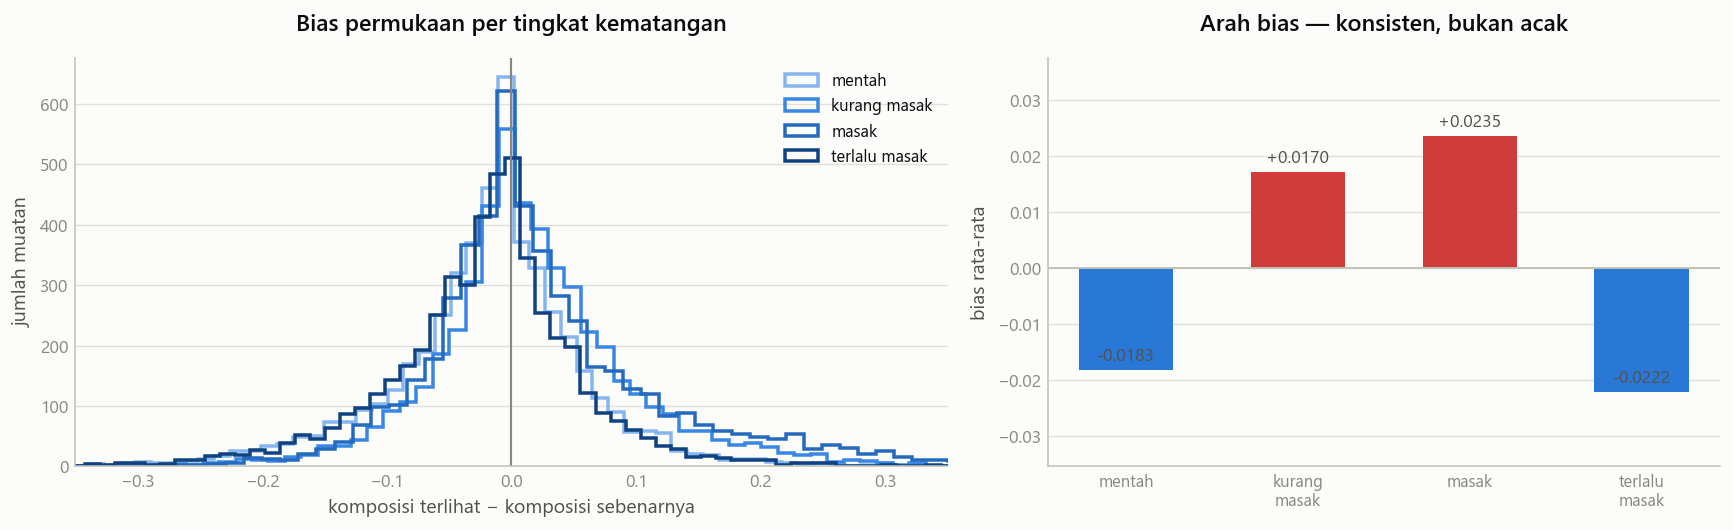

bias rata-rata (positif = terlalu terwakili di permukaan):
  mentah         -0.0183
  kurang_masak   +0.0170
  masak          +0.0235
  terlalu_masak  -0.0222


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9),
                         gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
for i, k in enumerate(KELAS):
    bias = te[f"lihat_{k}"] - te[f"benar_{k}"]
    ax.hist(bias, bins=70, histtype="step", linewidth=1.8,
            color=RAMP[i], label=k.replace("_", " "))
ax.axvline(0, color=vs.INK_MUTED, linewidth=1.1)
ax.set_xlabel("komposisi terlihat − komposisi sebenarnya")
ax.set_ylabel("jumlah muatan")
ax.set_title("Bias permukaan per tingkat kematangan")
ax.legend(fontsize=8.5)
ax.set_xlim(-0.35, 0.35)

ax = axes[1]
rerata = [(te[f"lihat_{k}"] - te[f"benar_{k}"]).mean() for k in KELAS]
warna = [vs.STATUS["critical"] if v > 0 else vs.CATEGORICAL[0] for v in rerata]
b = ax.bar(range(4), rerata, color=warna, width=0.55)
vs.label_bars(ax, b, fmt="{:+.4f}")
ax.axhline(0, color=vs.BASELINE, linewidth=1)
ax.set_xticks(range(4)); ax.set_xticklabels(LABEL, fontsize=8.5)
ax.set_ylabel("bias rata-rata")
ax.set_title("Arah bias — konsisten, bukan acak")
lo, hi = min(rerata), max(rerata)
ax.set_ylim(lo * 1.6 if lo < 0 else -0.005, hi * 1.6)
plt.tight_layout(); vs.show()

print("bias rata-rata (positif = terlalu terwakili di permukaan):")
for k, v in zip(KELAS, rerata):
    print(f"  {k:14s} {v:+.4f}")

> **Arahnya konsisten.** `masak` terlalu terwakili di permukaan, `mentah`
> dan `terlalu masak` kurang terwakili. Itu tanda tangan penataan sengaja:
> buah bagus di atas. Kalau bias ini diabaikan — yaitu memakai komposisi
> permukaan apa adanya — potensi minyak akan ditaksir terlalu tinggi secara
> sistematis, dan petani dengan muatan jujur dirugikan relatif terhadap yang
> menata muatannya.

## 2. Apakah selangnya jujur?

Dua pemeriksaan yang harus lolos bersamaan:

- **Cakupan** — selang 90% harus benar-benar memuat nilai sebenarnya ~90%
  dari waktu. Kurang dari itu berarti terlalu percaya diri.
- **Lebar vs lantai pencuplikan** — jauh lebih sempit dari lantai berarti
  mustahil; jauh lebih lebar berarti model belum memeras informasi.

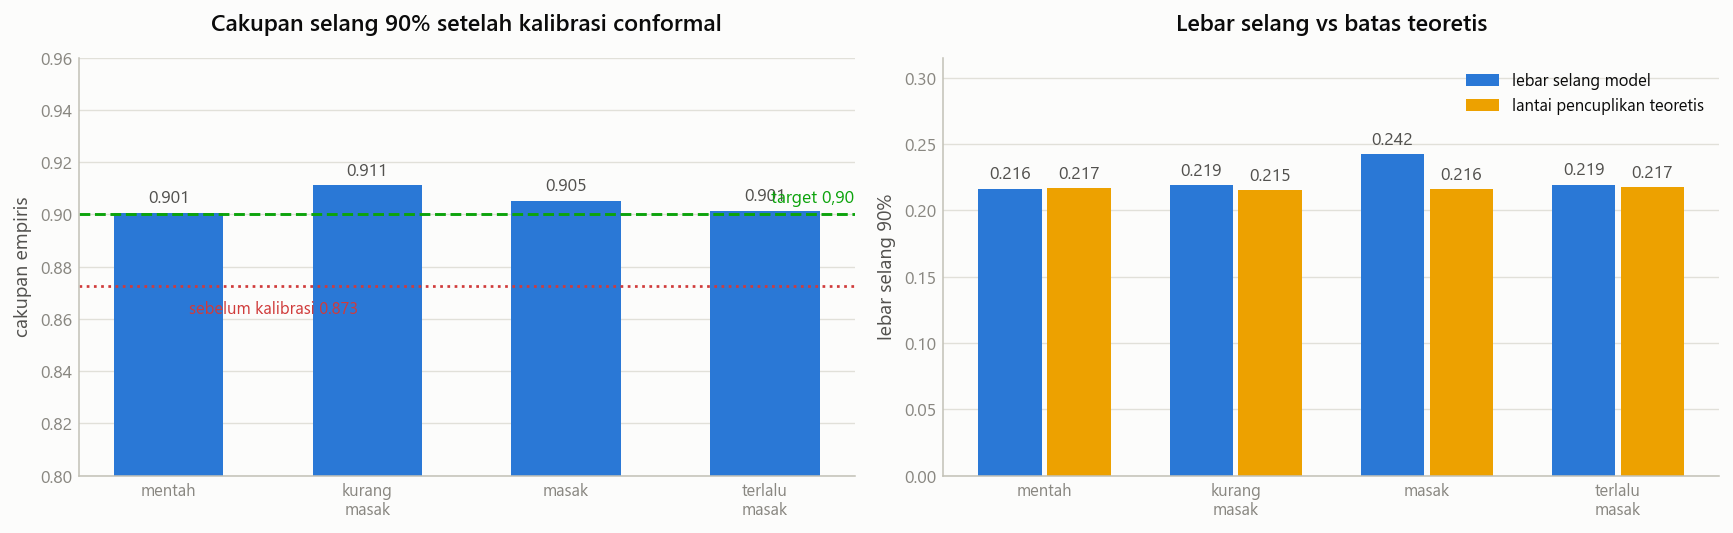

rasio lebar / lantai pencuplikan (1,0 = tepat di batas teoretis):
  mentah         0.999
  kurang_masak   1.017
  masak          1.122
  terlalu_masak  1.010


In [3]:
hasil = json.loads((ROOT / "docs" / "hasil_model2.json").read_text())
pk = pd.DataFrame(hasil["per_kelas"]).T

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))

ax = axes[0]
cak = pk["cakupan_90"].values
b = ax.bar(range(4), cak, color=vs.CATEGORICAL[0], width=0.55)
vs.label_bars(ax, b, fmt="{:.3f}")
ax.axhline(0.90, color=vs.STATUS["good"], linestyle="--", linewidth=1.5)
ax.annotate("target 0,90", (3.45, 0.90), xytext=(0, 6),
            textcoords="offset points", fontsize=9,
            color=vs.STATUS["good"], ha="right")
sebelum = hasil.get("cakupan_sebelum_kalibrasi")
if sebelum:
    ax.axhline(sebelum, color=vs.STATUS["critical"], linestyle=":", linewidth=1.4)
    ax.annotate(f"sebelum kalibrasi {sebelum:.3f}", (0.1, sebelum),
                xytext=(0, -14), textcoords="offset points", fontsize=8.5,
                color=vs.STATUS["critical"])
ax.set_xticks(range(4)); ax.set_xticklabels(LABEL, fontsize=8.5)
ax.set_ylim(0.8, 0.96); ax.set_ylabel("cakupan empiris")
ax.set_title("Cakupan selang 90% setelah kalibrasi conformal")

ax = axes[1]
x = np.arange(4); w = 0.36
b1 = ax.bar(x - w/2, pk["lebar_selang"].values, width=w*0.92,
            color=vs.CATEGORICAL[0], label="lebar selang model")
b2 = ax.bar(x + w/2, pk["lantai_pencuplikan_90"].values, width=w*0.92,
            color=vs.CATEGORICAL[3], label="lantai pencuplikan teoretis")
vs.label_bars(ax, b1, fmt="{:.3f}"); vs.label_bars(ax, b2, fmt="{:.3f}")
ax.set_xticks(x); ax.set_xticklabels(LABEL, fontsize=8.5)
ax.set_ylabel("lebar selang 90%")
ax.set_title("Lebar selang vs batas teoretis")
ax.legend(fontsize=8.5)
ax.set_ylim(0, max(pk["lebar_selang"]) * 1.3)
plt.tight_layout(); vs.show()

print("rasio lebar / lantai pencuplikan (1,0 = tepat di batas teoretis):")
for k, v in pk["rasio_lebar_thd_lantai"].items():
    print(f"  {k:14s} {v:.3f}")

> **Rasio mendekati 1,0 di semua tingkat.** Model berada tepat di lantai
> teoretis: sudah memeras seluruh informasi yang tersedia dari cuplikan
> permukaan, dan tidak mengaku tahu lebih banyak daripada yang dimungkinkan
> matematika.
>
> Ini juga menetapkan batas yang jujur untuk proposal: **selang tidak bisa
> dipersempit dengan model yang lebih canggih.** Satu-satunya cara adalah
> menambah jumlah tandan yang terlihat — lebih banyak sudut kamera, bukan
> arsitektur yang lebih rumit.

## 3. Di mana Model 2 benar-benar berguna?

Pembanding wajarnya bukan nol, melainkan **pendekatan naif**: anggap
komposisi permukaan = komposisi seluruh muatan. Itu yang dilakukan semua
sistem grading yang ada.

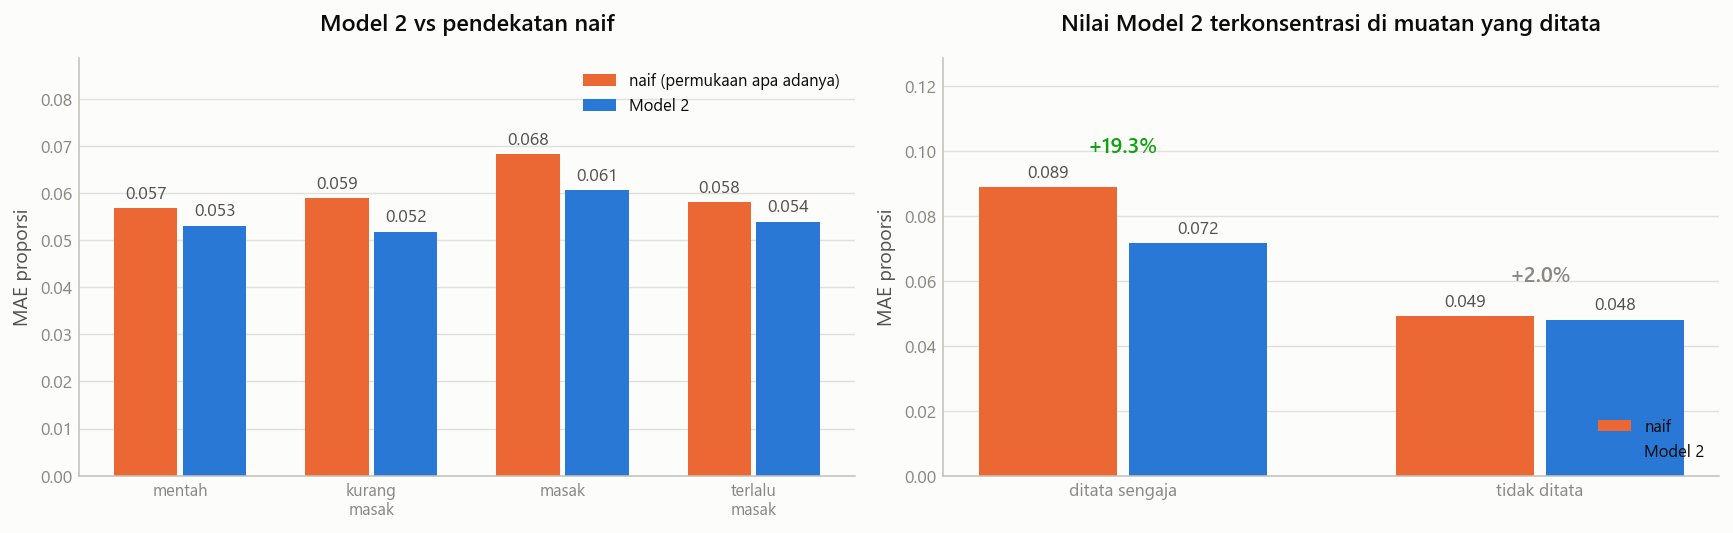

In [4]:
pecah = hasil.get("pecahan_karakter", {})
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))

ax = axes[0]
x = np.arange(4); w = 0.36
b1 = ax.bar(x - w/2, pk["MAE_naif"].values, width=w*0.92,
            color=vs.CATEGORICAL[1], label="naif (permukaan apa adanya)")
b2 = ax.bar(x + w/2, pk["MAE_model"].values, width=w*0.92,
            color=vs.CATEGORICAL[0], label="Model 2")
vs.label_bars(ax, b1, fmt="{:.3f}"); vs.label_bars(ax, b2, fmt="{:.3f}")
ax.set_xticks(x); ax.set_xticklabels(LABEL, fontsize=8.5)
ax.set_ylabel("MAE proporsi")
ax.set_title("Model 2 vs pendekatan naif")
ax.legend(fontsize=8.5)
ax.set_ylim(0, pk["MAE_naif"].max() * 1.3)

ax = axes[1]
if pecah:
    nama = list(pecah)
    naif = [pecah[n]["MAE_naif_rerata"] for n in nama]
    mdl = [pecah[n]["MAE_model_rerata"] for n in nama]
    perb = [pecah[n]["perbaikan_relatif"] * 100 for n in nama]
    x = np.arange(len(nama)); w = 0.36
    b1 = ax.bar(x - w/2, naif, width=w*0.92, color=vs.CATEGORICAL[1], label="naif")
    b2 = ax.bar(x + w/2, mdl, width=w*0.92, color=vs.CATEGORICAL[0], label="Model 2")
    vs.label_bars(ax, b1, fmt="{:.3f}"); vs.label_bars(ax, b2, fmt="{:.3f}")
    for i, p in enumerate(perb):
        ax.annotate(f"{p:+.1f}%", (i, max(naif[i], mdl[i])),
                    xytext=(0, 18), textcoords="offset points", ha="center",
                    fontsize=11, color=vs.STATUS["good"] if p > 10 else vs.INK_MUTED,
                    fontweight="600")
    ax.set_xticks(x); ax.set_xticklabels(nama, fontsize=9)
    ax.set_ylabel("MAE proporsi")
    ax.set_title("Nilai Model 2 terkonsentrasi di muatan yang ditata")
    ax.legend(fontsize=8.5, loc="lower right")
    ax.set_ylim(0, max(naif) * 1.45)
plt.tight_layout(); vs.show()

> **Inilah temuan terpenting Model 2.** Pada muatan jujur, koreksinya nyaris
> tidak berarti (+2%). Pada muatan yang ditata sengaja, ia memulihkan +19,3%.
>
> Artinya Model 2 bukan penambah akurasi umum — ia **mekanisme ketahanan
> terhadap penataan muatan**. Framing itu jauh lebih tepat, dan langsung
> menyambung ke sengketa potongan timbangan yang jadi latar belakang proyek.

## 4. Apakah model bergantung pada asumsi yang goyah?

Generator sintetik memodelkan mekanisme "tandan berat tenggelam". Tetapi
pemeriksaan atas data nyata menunjukkan ukuran kotak antar tingkat hanya
berselisih 11% — dasar empirisnya lemah.

Kalau model sangat bergantung pada asumsi itu, seluruh hasilnya rapuh. Diuji
dengan memecah data uji menurut kekuatan mekanisme tersebut, termasuk nol.

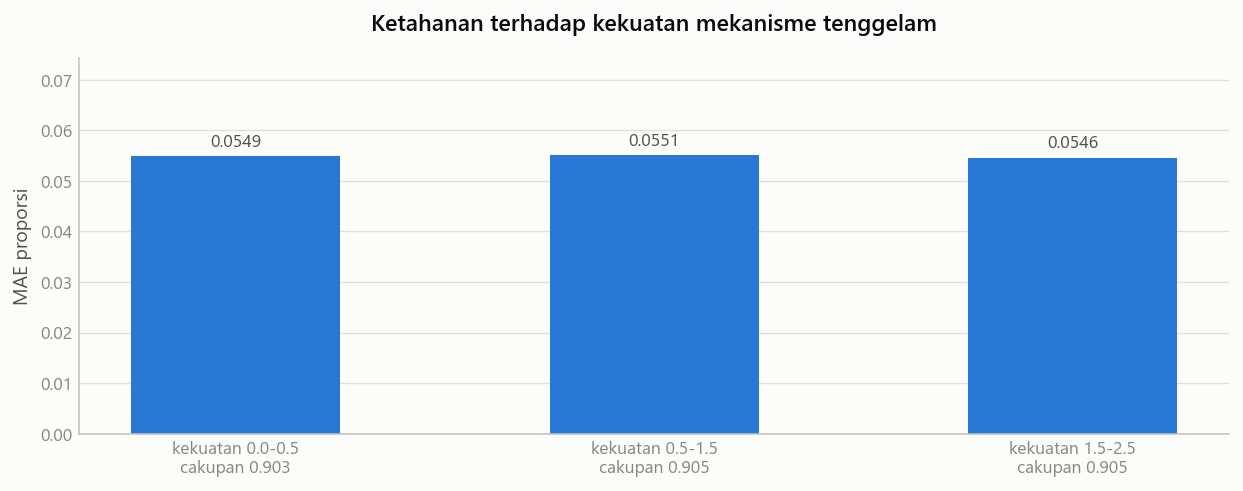

rentang MAE antar kelompok : 0.00048
relatif terhadap MAE rerata: 0.88%
-> model TIDAK bergantung pada asumsi yang dasar empirisnya lemah


In [5]:
tahan = hasil.get("ketahanan_tenggelam", {})
if tahan:
    fig, ax = plt.subplots(figsize=(9, 3.6))
    nama = list(tahan)
    mae = [tahan[n]["MAE_model_rerata"] for n in nama]
    cak = [tahan[n]["cakupan_90_rerata"] for n in nama]
    x = np.arange(len(nama))
    b = ax.bar(x, mae, color=vs.CATEGORICAL[0], width=0.5)
    vs.label_bars(ax, b, fmt="{:.4f}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"kekuatan {n}\ncakupan {c:.3f}"
                        for n, c in zip(nama, cak)], fontsize=9)
    ax.set_ylabel("MAE proporsi")
    ax.set_title("Ketahanan terhadap kekuatan mekanisme tenggelam")
    ax.set_ylim(0, max(mae) * 1.35)
    plt.tight_layout(); vs.show()

    rentang = max(mae) - min(mae)
    print(f"rentang MAE antar kelompok : {rentang:.5f}")
    print(f"relatif terhadap MAE rerata: {rentang/np.mean(mae)*100:.2f}%")
    print("-> model TIDAK bergantung pada asumsi yang dasar empirisnya lemah")

## 5. Model 4 — dari komposisi ke kilogram

Formula dasarnya aljabar sederhana yang bisa dihitung ulang dengan
kalkulator oleh siapa pun yang mempersoalkan hasilnya:

```
OER_teoretis   = basis_matang
rugi_komposisi = SUM( proporsi_kelas x penalti_kelas )
OER_realistis  = OER_teoretis + rugi_komposisi
potensi_kg     = berat_bruto x OER_realistis / 100
```

Seluruh koefisien dibaca dari `ai/config/coefficients.yaml`, tidak ada yang
ditulis di dalam kode.

UJI AKAL SEHAT
  100% matang -> 21.00 poin OER   LULUS
  100% mentah -> 8.00 poin OER   LULUS
  monoton turun                       LULUS


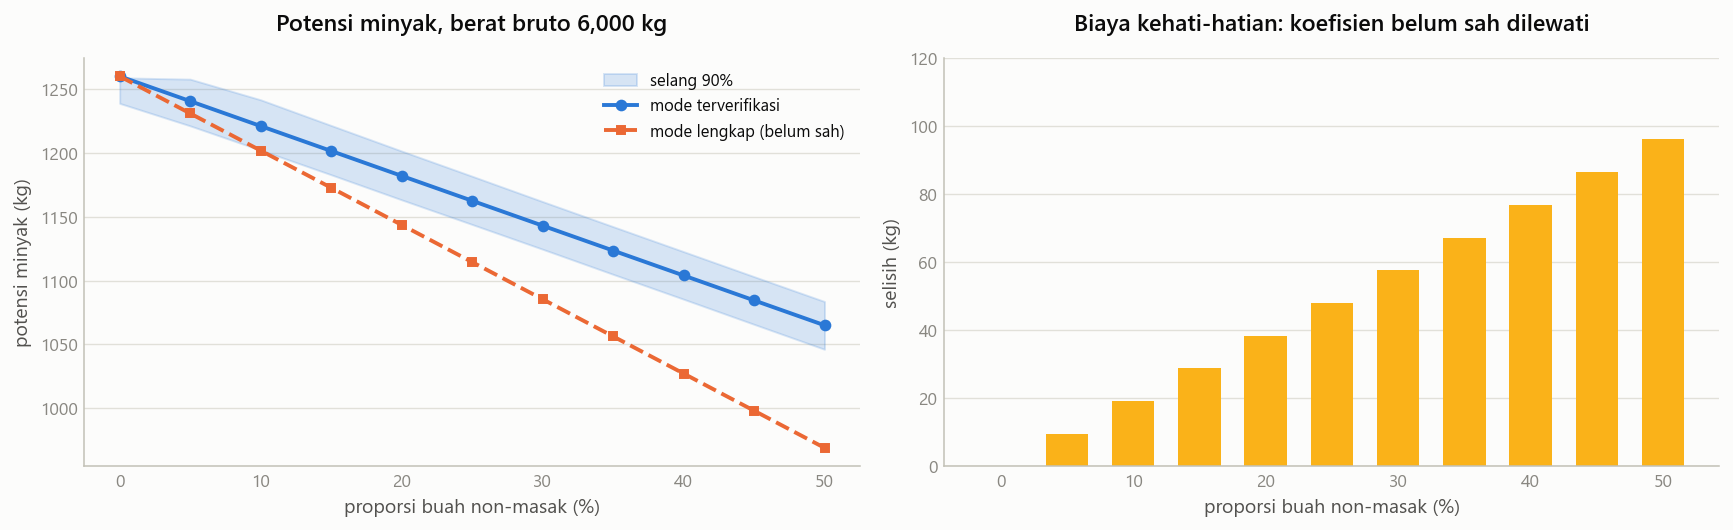


pada 20% non-masak: terverifikasi 1182 kg vs lengkap 1144 kg  (selisih 38 kg)


In [6]:
sc = M4.sanity_check(verbose=False)
print("UJI AKAL SEHAT")
print(f"  100% matang -> {sc['semua_matang_oer']:.2f} poin OER   "
      f"{'LULUS' if sc['lulus_1'] else 'GAGAL'}")
print(f"  100% mentah -> {sc['semua_mentah_oer']:.2f} poin OER   "
      f"{'LULUS' if sc['lulus_2'] else 'GAGAL'}")
print(f"  monoton turun                       "
      f"{'LULUS' if sc['lulus_3'] else 'GAGAL'}")

berat = 6000.0
pct = np.arange(0, 55, 5)
# muatan buruk tidak pernah "mentah saja" — ketiga tingkat non-masak naik
# bersama. Bagiannya diambil dari sebaran muatan campuran di data nyata.
BAGI = {"mentah": 0.50, "kurang_masak": 0.35, "terlalu_masak": 0.15}
kg_ver, lo_ver, hi_ver, kg_lkp = [], [], [], []
for p in pct:
    komp = {k: p/100 * f for k, f in BAGI.items()}
    komp["masak"] = 1 - p/100
    selang = {k: (max(0, v-0.03), v, min(1, v+0.03)) for k, v in komp.items()}
    hv = M4.hitung_dengan_selang(selang, berat, mode="terverifikasi")
    hl = M4.hitung_dengan_selang(selang, berat, mode="lengkap")
    kg_ver.append(hv.potensi_kg); lo_ver.append(hv.potensi_lo)
    hi_ver.append(hv.potensi_hi); kg_lkp.append(hl.potensi_kg)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))

ax = axes[0]
ax.fill_between(pct, lo_ver, hi_ver, color=vs.CATEGORICAL[0], alpha=0.18,
                label="selang 90%")
ax.plot(pct, kg_ver, color=vs.CATEGORICAL[0], marker="o", markersize=5,
        label="mode terverifikasi")
ax.plot(pct, kg_lkp, color=vs.CATEGORICAL[1], marker="s", markersize=4,
        linestyle="--", label="mode lengkap (belum sah)")
ax.set_xlabel("proporsi buah non-masak (%)")
ax.set_ylabel("potensi minyak (kg)")
ax.set_title(f"Potensi minyak, berat bruto {berat:,.0f} kg")
ax.legend(fontsize=8.5)

ax = axes[1]
selisih = np.array(kg_ver) - np.array(kg_lkp)
b = ax.bar(pct, selisih, color=vs.STATUS["warning"], width=3.2)
ax.set_xlabel("proporsi buah non-masak (%)")
ax.set_ylabel("selisih (kg)")
ax.set_title("Biaya kehati-hatian: koefisien belum sah dilewati")
ax.set_ylim(0, selisih.max() * 1.25)
plt.tight_layout(); vs.show()

print()
print(f"pada 20% non-masak: terverifikasi {kg_ver[4]:.0f} kg vs "
      f"lengkap {kg_lkp[4]:.0f} kg  (selisih {kg_ver[4]-kg_lkp[4]:.0f} kg)")

> **Selisih dua mode itu bukan galat, melainkan kehati-hatian yang disengaja.**
> Mode bawaan menolak dua penalti yang belum terverifikasi ke sumber terbit,
> memperlakukannya nol, sehingga kehilangan sisi pemasok ditaksir lebih rendah.
> Arah kesalahannya benar: kalau ragu, jangan merugikan petani.
>
> Efek sampingnya disebut terus terang — potensi realistis jadi lebih tinggi,
> selisih menuju rendemen aktual melebar, dan kehilangan itu berpindah ke sisi
> pabrik. Itu pilihan sadar: pabrik punya kemampuan menyelidiki, petani tidak.

## 6. Rantai ketidakpastian, dirambatkan utuh

```
Model 1  deteksi per tandan        ±e1
   |
Model 2  komposisi muatan          ±e2     <- melebar: oklusi + pencuplikan
   |
Model 4  potensi minyak (kg)       ±e3
```

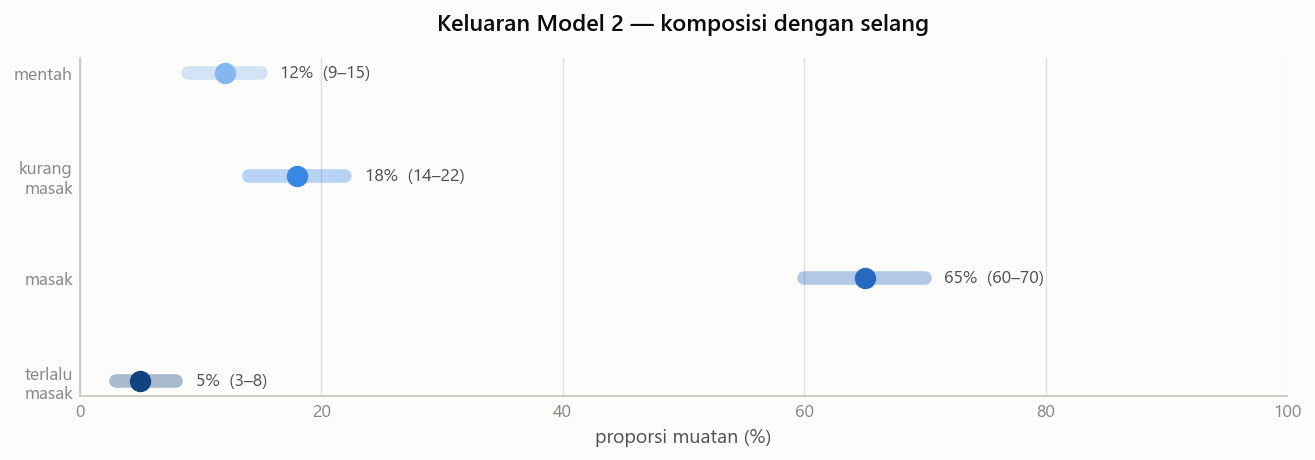

  OER teoretis   : 21.00 poin
  rugi komposisi : -1.560 poin  -> sisi PEMASOK
  OER realistis  : 19.440 poin
----------------------------------------------------------
  POTENSI MINYAK : 1,166 kg
  selang 90%     : 1,148 - 1,186 kg (lebar 39 kg)
  dasar sah      : True


In [7]:
contoh = {
    "mentah":        (0.09, 0.12, 0.15),
    "kurang_masak":  (0.14, 0.18, 0.22),
    "masak":         (0.60, 0.65, 0.70),
    "terlalu_masak": (0.03, 0.05, 0.08),
}
h = M4.hitung_dengan_selang(contoh, 6000.0)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
y = np.arange(4)
for i, k in enumerate(KELAS):
    lo, v, hi = contoh[k]
    ax.plot([lo*100, hi*100], [i, i], color=RAMP[i], linewidth=7, alpha=0.35,
            solid_capstyle="round")
    ax.plot([v*100], [i], marker="o", markersize=10, color=RAMP[i])
    ax.annotate(f"{v*100:.0f}%  ({lo*100:.0f}–{hi*100:.0f})",
                (hi*100, i), xytext=(10, 0), textcoords="offset points",
                va="center", fontsize=9, color=vs.INK_SECONDARY)
ax.set_yticks(y); ax.set_yticklabels(LABEL, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 100)
ax.set_xlabel("proporsi muatan (%)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Keluaran Model 2 — komposisi dengan selang")
plt.tight_layout(); vs.show()

print("=" * 58)
print(f"  OER teoretis   : {h.oer_teoretis:.2f} poin")
print(f"  rugi komposisi : {h.rugi_komposisi:+.3f} poin  -> sisi PEMASOK")
print(f"  OER realistis  : {h.oer_realistis:.3f} poin")
print("-" * 58)
print(f"  POTENSI MINYAK : {h.potensi_kg:,.0f} kg")
print(f"  selang 90%     : {h.potensi_lo:,.0f} - {h.potensi_hi:,.0f} kg "
      f"(lebar {h.lebar_selang:,.0f} kg)")
print(f"  dasar sah      : {h.dasar_sah}")
print("=" * 58)

## Kesimpulan

**Model 2 — komposisi dari permukaan**

| Yang diperiksa | Hasil |
|---|---|
| MAE vs pendekatan naif | 0,0548 vs 0,0605 — **+9,3%** |
| Cakupan selang 90% | 0,8726 → **0,9046** setelah kalibrasi conformal |
| Lebar selang / lantai pencuplikan | 0,999 / 1,017 / 1,122 / 1,010 |
| Muatan **ditata sengaja** | **+19,3%** |
| Muatan **jujur** | +2,0% |
| Ketahanan thd asumsi tenggelam | rentang MAE hanya **0,88%** |

Tiga hal yang layak dinyatakan di proposal:

1. **Selangnya jujur.** Rasio ≈1,0 terhadap lantai pencuplikan berarti model
   sudah memeras seluruh informasi yang tersedia, dan tidak mengaku tahu
   lebih banyak. Konsekuensinya juga jujur: selang tidak bisa dipersempit
   dengan arsitektur yang lebih canggih — hanya dengan lebih banyak tandan
   terlihat.

2. **Nilainya terkonsentrasi, bukan merata.** Model 2 adalah mekanisme
   ketahanan terhadap penataan muatan, bukan penambah akurasi umum. Pada
   muatan jujur, koreksinya nyaris nihil — dan memang seharusnya begitu.

3. **Tidak bergantung pada asumsi yang lemah.** Mekanisme "tandan berat
   tenggelam" dasar empirisnya tipis (selisih ukuran hanya 11%). MAE tetap
   rata di seluruh rentang kekuatan mekanisme, termasuk nol.

**Model 4 — komposisi menjadi kilogram**

Tiga uji akal sehat lolos. Formulanya bisa dihitung ulang dengan kalkulator
oleh pihak yang mempersoalkan hasilnya — sifat yang penting untuk alat yang
dipakai dalam sengketa harga.

Disiplin koefisien terlihat dampaknya: pada muatan dengan 20% buah non-masak,
mode `terverifikasi` melaporkan 1.182 kg sedangkan mode `lengkap` 1.144 kg.
Selisih 38 kg itu bukan galat, melainkan penolakan memakai dua penalti yang
belum tertelusur ke sumber terbit. Arah kesalahannya disengaja: **kalau ragu,
jangan merugikan petani** — kehilangan yang belum terbukti berpindah ke sisi
pabrik, pihak yang punya kemampuan menyelidikinya.

**Batas yang harus disebut**

Model 2 divalidasi terhadap simulatornya sendiri. Kebenaran sesungguhnya —
komposisi satu truk penuh — memerlukan pembongkaran dan penyortiran manual,
yang belum dilakukan. Angka di atas sah sebagai bukti bahwa **metodenya
benar**, bukan sebagai jaminan akurasi lapangan. Pengujian lapangan pada
beberapa truk masuk daftar pekerjaan lanjutan, bukan klaim yang sudah lunas.

---

Berikutnya: **Model 5** — mempertemukan potensi ini dengan rendemen aktual
pabrik, dan membagi selisihnya menjadi kehilangan yang bisa dijelaskan
(pemasok, pabrik) dan sisa yang tidak bisa.